In [181]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [182]:
words = open(file='./data/names.txt', mode = 'r').read().splitlines()
print(max([len(w) for w in words]))
print(words[:8])
chars = set(''.join(words))
chars =sorted(list(chars))
stoi = {k : v+1 for v, k in enumerate(chars)}
stoi['.'] = 0
itos = {k:v for v, k in stoi.items()}
vocab_size = len(stoi)
print(vocab_size)

15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
27


In [183]:
print(words)

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn', 'abigail', 'emily', 'elizabeth', 'mila', 'ella', 'avery', 'sofia', 'camila', 'aria', 'scarlett', 'victoria', 'madison', 'luna', 'grace', 'chloe', 'penelope', 'layla', 'riley', 'zoey', 'nora', 'lily', 'eleanor', 'hannah', 'lillian', 'addison', 'aubrey', 'ellie', 'stella', 'natalie', 'zoe', 'leah', 'hazel', 'violet', 'aurora', 'savannah', 'audrey', 'brooklyn', 'bella', 'claire', 'skylar', 'lucy', 'paisley', 'everly', 'anna', 'caroline', 'nova', 'genesis', 'emilia', 'kennedy', 'samantha', 'maya', 'willow', 'kinsley', 'naomi', 'aaliyah', 'elena', 'sarah', 'ariana', 'allison', 'gabriella', 'alice', 'madelyn', 'cora', 'ruby', 'eva', 'serenity', 'autumn', 'adeline', 'hailey', 'gianna', 'valentina', 'isla', 'eliana', 'quinn', 'nevaeh', 'ivy', 'sadie', 'piper', 'lydia', 'alexa', 'josephine', 'emery', 'julia', 'delilah', 'arianna', 'vivian', 'kaylee', 'sophie', 'brielle', 'madeline', 'peyton', 'ryle

In [184]:
import random
random.shuffle(words)
print(words)

['rownan', 'locke', 'layonna', 'abdourahmane', 'jabali', 'dareon', 'xena', 'ellisyn', 'golden', 'ziyanna', 'fajr', 'lorde', 'xzayvion', 'christos', 'deonta', 'cloie', 'svea', 'jaylani', 'aleema', 'cason', 'dasir', 'samriddhi', 'ivon', 'jaheem', 'thia', 'anchor', 'desarae', 'lazlo', 'jazly', 'lakshmi', 'akeyla', 'sharaya', 'chisimdi', 'isobella', 'omni', 'relic', 'jaquell', 'mavi', 'ahlana', 'amora', 'daeson', 'lilley', 'kaenen', 'baani', 'jaser', 'humza', 'tarini', 'jamaria', 'jayliani', 'tresean', 'sulayman', 'monai', 'markella', 'elisheva', 'fairy', 'francisca', 'alai', 'ember', 'ryman', 'rece', 'niklas', 'ridley', 'panav', 'dalia', 'kierstin', 'anastasiya', 'vaanya', 'murray', 'hosna', 'robbie', 'cadence', 'neo', 'kasi', 'keanan', 'nailah', 'arin', 'mckenleigh', 'aidin', 'maura', 'rosetta', 'zakaiya', 'ralphael', 'marlowe', 'raavi', 'valerio', 'asja', 'emani', 'areg', 'sanah', 'tobyn', 'nnamdi', 'giordano', 'menucha', 'shyne', 'qamar', 'ryver', 'madden', 'mayanna', 'shreenika', 'mad

In [185]:
block_size = 3

In [186]:
### build dataset
def build_dataset(words):
    """
    根据字符级语言模型构建训练数据集，将单词序列转换为上下文-目标对
    
    Args:
        words (list[str]): 单词列表，每个单词为字符串形式
    
    Returns:
        tuple[torch.Tensor, torch.Tensor]: 包含两个张量的元组
            - X (torch.Tensor): 上下文输入张量，形状为 (N, block_size)
            - Y (torch.Tensor): 目标字符索引张量，形状为 (N,)
    """
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
n1 = int(len(words) * 0.8) 
n2 = int(len(words) * 0.9)
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182605, 3]) torch.Size([182605])
torch.Size([22641, 3]) torch.Size([22641])
torch.Size([22900, 3]) torch.Size([22900])


In [187]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join([itos[ix.item()] for ix in x]),'--->', itos[y.item()])

... ---> r
..r ---> o
.ro ---> w
row ---> n
own ---> a
wna ---> n
nan ---> .
... ---> l
..l ---> o
.lo ---> c
loc ---> k
ock ---> e
cke ---> .
... ---> l
..l ---> a
.la ---> y
lay ---> o
ayo ---> n
yon ---> n
onn ---> a


In [188]:
class Linear:
    def __init__(self, f_in, f_out, bias = True):
        self.weight = torch.randn(size=(f_in, f_out)) / f_in ** 0.5
        self.bias = torch.zeros(size=(f_out,)) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight 
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + [self.bias] if self.bias is not None else [self.weight]

class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps 
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    def __call__(self, x):
        if self.training:
            xmean = x.mean(dim = 0, keepdim=True)
            xvar = x.var(dim = 0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [189]:
n_emb = 10
n_hidden = 200
C = torch.randn(size = (vocab_size, n_emb))
layers = [Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
          Linear(n_hidden, vocab_size)]
with torch.no_grad():
    layers[-1].weight *= 0.1
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.numel() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [190]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    ix = torch.randint(low = 0, high=Xtr.shape[0], size = (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    x = emb.reshape(Xb.size(0), -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    if (i % 10000) == 0 :
        print(f'{i} / {max_steps}: {loss.item()}')
    lossi.append(loss.detach().item())

0 / 200000: 3.3234920501708984
10000 / 200000: 2.133112668991089
20000 / 200000: 2.087963819503784
30000 / 200000: 2.615039587020874
40000 / 200000: 2.26436448097229
50000 / 200000: 1.9435776472091675
60000 / 200000: 2.1895241737365723
70000 / 200000: 2.188937187194824
80000 / 200000: 2.506971836090088
90000 / 200000: 1.8761858940124512
100000 / 200000: 2.1460087299346924
110000 / 200000: 2.4579341411590576
120000 / 200000: 1.9015637636184692
130000 / 200000: 2.3090696334838867
140000 / 200000: 2.510523796081543
150000 / 200000: 2.7010977268218994
160000 / 200000: 2.4404990673065186
170000 / 200000: 2.2030022144317627
180000 / 200000: 2.051352024078369
190000 / 200000: 2.239494800567627


In [191]:
print(loss.item())

2.2168803215026855


In [192]:
import math
# lossi[0]
lossi_log = [0] * len(lossi)
for i in range(len(lossi_log)):
    lossi_log[i] = math.log10(lossi[i])

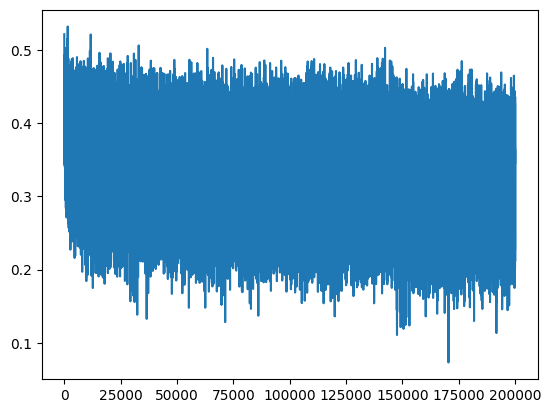

In [193]:
plt.plot(lossi_log)

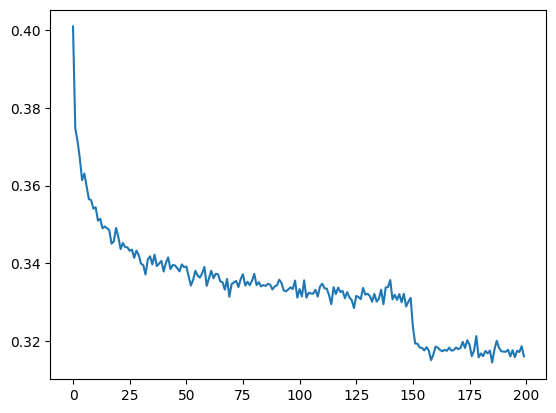

In [194]:
plt.plot(torch.tensor(lossi_log).view(200,-1).mean(dim = 1))

In [195]:
@torch.no_grad()
def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
           'dev': (Xdev, Ydev),
           'test':(Xte, Yte)}[split]
    emb = C[x]
    x = emb.view(x.size(0), -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(loss.item())
split_loss('dev')

2.122903823852539


In [206]:
@torch.no_grad()
def sample():
    # 切 eval
    for layer in layers:
        if isinstance(layer, BatchNorm1d):
            layer.training = False
    
    for _ in range(20):
        out = []
        context = [0] * block_size
        while True:
            emb = C[torch.tensor([context])]
            x = emb.view(1, -1)
            # print(x.shape)
            for layer in layers:
                x = layer(x)
            logits = x
            probs = F.softmax(logits, dim=1)
            # print(probs.shape)
            ix = torch.multinomial(probs, num_samples=1).item()
            context = context[1:] + [ix]
            out.append(ix)
            if ix == 0:
                break
        print(''.join(itos[i] for i in out))

In [207]:
sample()

owyndelyk.
shwina.
kyamilit.
jayvieriza.
zaver.
legravera.
laidast.
pael.
sayan.
willi.
alen.
jakaishika.
maislee.
abdoriel.
doyalloeana.
kunasa.
chardo.
niclissa.
jaheancarlennikamsalpe.
mariyah.


## 改进

In [218]:
class Linear:
    def __init__(self, f_in, f_out, bias = True):
        self.weight = torch.randn(size=(f_in, f_out)) / f_in ** 0.5
        self.bias = torch.zeros(size=(f_out,)) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight 
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + [self.bias] if self.bias is not None else [self.weight]

class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps 
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    def __call__(self, x):
        if self.training:
            xmean = x.mean(dim = 0, keepdim=True)
            xvar = x.var(dim = 0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embedding, embedding_dim):
        self.weight = torch.randn(size = (num_embedding, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class Flatten:
    def __call__(self, x):
        self.out = x.reshape(x.shape[0], -1)
        return self.out
    def parameters(self):
        return []        

In [219]:
n_emb = 10
n_hidden = 200
layers = [Embedding(vocab_size, n_emb), Flatten(),
          Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
          Linear(n_hidden, vocab_size)]
with torch.no_grad():
    layers[-1].weight *= 0.1
parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.numel() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [221]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    ix = torch.randint(low = 0, high=Xtr.shape[0], size = (batch_size,))
    x, y = Xtr[ix], Ytr[ix]
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    if (i % 10000) == 0 :
        print(f'{i} / {max_steps}: {loss.item()}')
    lossi.append(loss.log10().detach().item())

0 / 200000: 3.34837007522583
10000 / 200000: 2.3607475757598877
20000 / 200000: 2.365846872329712
30000 / 200000: 2.1702187061309814
40000 / 200000: 2.0838210582733154
50000 / 200000: 1.7085237503051758
60000 / 200000: 2.2825522422790527
70000 / 200000: 2.4034626483917236
80000 / 200000: 2.285639524459839
90000 / 200000: 2.201873302459717
100000 / 200000: 2.1276731491088867
110000 / 200000: 2.010054111480713
120000 / 200000: 1.70445716381073
130000 / 200000: 2.286890983581543
140000 / 200000: 2.3837711811065674
150000 / 200000: 2.072021007537842
160000 / 200000: 2.1682865619659424
170000 / 200000: 2.358480930328369
180000 / 200000: 2.2575371265411377
190000 / 200000: 2.501072406768799


## 使用 container 容器，并实现 Sequential 类

In [254]:
class Linear:
    def __init__(self, f_in, f_out, bias = True):
        self.weight = torch.randn(size=(f_in, f_out)) / f_in ** 0.5
        self.bias = torch.zeros(size=(f_out,)) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight 
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + [self.bias] if self.bias is not None else [self.weight]

class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps 
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    def __call__(self, x):
        if self.training:
            xmean = x.mean(dim = 0, keepdim=True)
            xvar = x.var(dim = 0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embedding, embedding_dim):
        self.weight = torch.randn(size = (num_embedding, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class Flatten:
    def __call__(self, x):
        self.out = x.reshape(x.shape[0], -1)
        return self.out
    def parameters(self):
        return []        

class Sequential:
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [255]:
n_emb = 10
n_hidden = 200
model = Sequential([Embedding(vocab_size, n_emb), Flatten(),
          Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
          Linear(n_hidden, vocab_size)])
with torch.no_grad():
    layers[-1].weight *= 0.1
parameters = model.parameters()
print(sum(p.numel() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [256]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    ix = torch.randint(low = 0, high=Xtr.shape[0], size = (batch_size,))
    x, y = Xtr[ix], Ytr[ix]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    if (i % 10000) == 0 :
        print(f'{i} / {max_steps}: {loss.item()}')
    lossi.append(loss.log10().detach().item())

0 / 200000: 3.5384111404418945
10000 / 200000: 1.9043067693710327
20000 / 200000: 2.4060394763946533
30000 / 200000: 1.9126904010772705
40000 / 200000: 2.109152317047119
50000 / 200000: 2.335742235183716
60000 / 200000: 2.512451648712158
70000 / 200000: 2.031362295150757
80000 / 200000: 2.278972625732422
90000 / 200000: 2.6299126148223877
100000 / 200000: 1.889035701751709
110000 / 200000: 2.0796890258789062
120000 / 200000: 2.142014265060425
130000 / 200000: 2.1456003189086914
140000 / 200000: 2.7057297229766846
150000 / 200000: 2.1956684589385986
160000 / 200000: 2.098360061645508
170000 / 200000: 1.9217605590820312
180000 / 200000: 2.0115833282470703
190000 / 200000: 1.7370387315750122


In [257]:
for layer in model.layers:
        layer.training = False

In [258]:
@torch.no_grad()
def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
           'dev': (Xdev, Ydev),
           'test':(Xte, Yte)}[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(loss.item())
split_loss('dev')
split_loss('train')

2.1268885135650635
2.058885335922241


In [259]:
@torch.no_grad()
def sample():
    for _ in range(20):
        out = []
        context = [0] * block_size
        while True:
            logits = model([torch.tensor([context])])
            # print(logits)
            probs = F.softmax(logits, dim=1)
            # print(probs.shape)
            ix = torch.multinomial(probs, num_samples=1).item()
            context = context[1:] + [ix]
            out.append(ix)
            if ix == 0:
                break
        print(''.join(itos[i] for i in out))

In [260]:
sample()

lynn.
garron.
traylaren.
mikai.
ken.
eby.
huxiel.
brie.
sataley.
barrie.
keila.
mayum.
juvyn.
len.
maryaira.
maddy.
mcky.
moarya.
merick.
gina.


/var/folders/w9/1b86t9ss4m9bn63rhf_hwc5c0000gp/T/ipykernel_19597/3370935432.py:53: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  self.out = self.weight[IX]


## Achieve hierarchical organization.

In [261]:
class Linear:
    def __init__(self, f_in, f_out, bias = True):
        self.weight = torch.randn(size=(f_in, f_out)) / f_in ** 0.5
        self.bias = torch.zeros(size=(f_out,)) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight 
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + [self.bias] if self.bias is not None else [self.weight]

class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps 
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    def __call__(self, x):
        if self.training:
            xmean = x.mean(dim = 0, keepdim=True)
            xvar = x.var(dim = 0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embedding, embedding_dim):
        self.weight = torch.randn(size = (num_embedding, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class Flatten:
    def __call__(self, x):
        self.out = x.reshape(x.shape[0], -1)
        return self.out
    def parameters(self):
        return []        

class Sequential:
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [262]:
block_size = 8
### build dataset
def build_dataset(words):
    """
    根据字符级语言模型构建训练数据集，将单词序列转换为上下文-目标对
    
    Args:
        words (list[str]): 单词列表，每个单词为字符串形式
    
    Returns:
        tuple[torch.Tensor, torch.Tensor]: 包含两个张量的元组
            - X (torch.Tensor): 上下文输入张量，形状为 (N, block_size)
            - Y (torch.Tensor): 目标字符索引张量，形状为 (N,)
    """
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
n1 = int(len(words) * 0.8) 
n2 = int(len(words) * 0.9)
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182605, 8]) torch.Size([182605])
torch.Size([22641, 8]) torch.Size([22641])
torch.Size([22900, 8]) torch.Size([22900])


In [263]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join([itos[ix.item()] for ix in x]),'--->', itos[y.item()])

........ ---> r
.......r ---> o
......ro ---> w
.....row ---> n
....rown ---> a
...rowna ---> n
..rownan ---> .
........ ---> l
.......l ---> o
......lo ---> c
.....loc ---> k
....lock ---> e
...locke ---> .
........ ---> l
.......l ---> a
......la ---> y
.....lay ---> o
....layo ---> n
...layon ---> n
..layonn ---> a


In [266]:
n_emb = 10
n_hidden = 200
model = Sequential([Embedding(vocab_size, n_emb), Flatten(),
          Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
          Linear(n_hidden, vocab_size)])
with torch.no_grad():
    layers[-1].weight *= 0.1
parameters = model.parameters()
print(sum(p.numel() for p in parameters))
for p in parameters:
    p.requires_grad = True

22097


In [282]:
### 形状测试
ix = torch.randint(low = 0, high=Xtr.shape[0], size=(4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(logits.shape)

torch.Size([4, 27])


In [292]:
model.layers

In [294]:
print(model.layers[0].out.shape)
print(model.layers[1].out.shape)
print(model.layers[2].out.shape)
print(model.layers[3].out.shape)
print(model.layers[4].out.shape)
print(model.layers[5].out.shape)

torch.Size([4, 8, 10])
torch.Size([4, 80])
torch.Size([4, 200])
torch.Size([4, 200])
torch.Size([4, 200])
torch.Size([4, 27])


### 有趣的现象

In [ ]:
torch.manual_seed(1)
matrix = torch.randn(size=(2,2,4))
print(matrix)
print(matrix[:, ::2, :])
print(matrix[:, 1::2, :])
manual = torch.cat([matrix[:, ::2, :], matrix[:, 1::2, :]] , dim = -1)
explicit= matrix.view(2, 1, 8)
(manual == explicit).all()

tensor([[[-1.5256, -0.7502, -0.6540, -1.6095],
         [-0.1002, -0.6092, -0.9798, -1.6091]],

        [[-0.7121,  0.3037, -0.7773, -0.2515],
         [-0.2223,  1.6871,  0.2284,  0.4676]]])
tensor([[[-1.5256, -0.7502, -0.6540, -1.6095]],

        [[-0.7121,  0.3037, -0.7773, -0.2515]]])
tensor([[[-0.1002, -0.6092, -0.9798, -1.6091]],

        [[-0.2223,  1.6871,  0.2284,  0.4676]]])


tensor(True)

In [267]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    ix = torch.randint(low = 0, high=Xtr.shape[0], size = (batch_size,))
    x, y = Xtr[ix], Ytr[ix]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    if (i % 10000) == 0 :
        print(f'{i} / {max_steps}: {loss.item()}')
    lossi.append(loss.log10().detach().item())
    # break

0 / 200000: 3.4801242351531982
10000 / 200000: 2.445058822631836
20000 / 200000: 2.1655516624450684
30000 / 200000: 1.864422082901001
40000 / 200000: 2.2932331562042236
50000 / 200000: 2.1361584663391113
60000 / 200000: 1.8466367721557617
70000 / 200000: 1.7907088994979858
80000 / 200000: 2.0000240802764893
90000 / 200000: 1.8200571537017822
100000 / 200000: 2.236327648162842
110000 / 200000: 1.9172736406326294
120000 / 200000: 2.2607569694519043
130000 / 200000: 1.8640315532684326
140000 / 200000: 2.2962608337402344
150000 / 200000: 1.927343487739563
160000 / 200000: 1.781259298324585
170000 / 200000: 2.2703769207000732
180000 / 200000: 1.7785171270370483
190000 / 200000: 2.237032175064087


In [268]:
for layer in model.layers:
        layer.training = False

In [269]:
@torch.no_grad()
def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
           'dev': (Xdev, Ydev),
           'test':(Xte, Yte)}[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(loss.item())
split_loss('dev')
split_loss('train')

2.0400238037109375
1.9179611206054688


### Performance log
- previous : val 2.1268885135650635; train 2.058885335922241
- now : val 2.0400238037109375; train 1.9179611206054688

## wavnet

In [344]:
class Linear:
    def __init__(self, f_in, f_out, bias = True):
        self.weight = torch.randn(size=(f_in, f_out)) / f_in ** 0.5
        self.bias = torch.zeros(size=(f_out,)) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight 
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + [self.bias] if self.bias is not None else [self.weight]

class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps 
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    def __call__(self, x):
        if x.ndim == 2:
            dim = 0
        elif x.ndim == 3:
            dim = (0,1)
        if self.training:
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embedding, embedding_dim):
        self.weight = torch.randn(size = (num_embedding, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        self.out = x.reshape(B, T // self.n, C*self.n)
        if T // self.n == 1:
            self.out = self.out.squeeze(1) 
        return self.out
    def parameters(self):
        return []        

class Sequential:
    def __init__(self, layers):
        self.layers = layers
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        

In [345]:
n_emb = 10
n_hidden = 68
model = Sequential([Embedding(vocab_size, n_emb), 
        FlattenConsecutive(2), Linear(20, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
        FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
        FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
        Linear(n_hidden, vocab_size)])
with torch.no_grad():
    layers[-1].weight *= 0.1
parameters = model.parameters()
print(sum(p.numel() for p in parameters))
for p in parameters:
    p.requires_grad = True

22397


In [346]:
### 形状测试
ix = torch.randint(low = 0, high=Xtr.shape[0], size=(4,))
Xb, Yb = Xtr[ix], Ytr[ix]
print(Xb)
logits = model(Xb)
print(logits.shape)

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0, 19,  5, 12, 12,  5],
        [ 0,  0, 25,  5,  4,  9,  4, 25],
        [ 0,  0,  0,  0,  0,  0,  0,  5]])
torch.Size([4, 27])


In [347]:
for layer in model.layers:
    print(layer.__class__.__name__, layer.out.shape)

Embedding torch.Size([4, 8, 10])
FlattenConsecutive torch.Size([4, 4, 20])
Linear torch.Size([4, 4, 68])
BatchNorm1d torch.Size([4, 4, 68])
Tanh torch.Size([4, 4, 68])
FlattenConsecutive torch.Size([4, 2, 136])
Linear torch.Size([4, 2, 68])
BatchNorm1d torch.Size([4, 2, 68])
Tanh torch.Size([4, 2, 68])
FlattenConsecutive torch.Size([4, 136])
Linear torch.Size([4, 68])
BatchNorm1d torch.Size([4, 68])
Tanh torch.Size([4, 68])
Linear torch.Size([4, 27])


In [348]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    ix = torch.randint(low = 0, high=Xtr.shape[0], size = (batch_size,))
    x, y = Xtr[ix], Ytr[ix]
    # print(x.shape)
    logits = model(x)
    # logits = logits.squeeze(1)
    # print(logits.shape)
    loss = F.cross_entropy(logits, y)
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    if (i % 10000) == 0 :
        print(f'{i} / {max_steps}: {loss.item()}')
    lossi.append(loss.log10().detach().item())
    # break

0 / 200000: 3.3423469066619873
10000 / 200000: 2.5495970249176025
20000 / 200000: 2.2760355472564697
30000 / 200000: 1.6874628067016602
40000 / 200000: 2.1579275131225586
50000 / 200000: 2.481881618499756
60000 / 200000: 2.0635576248168945
70000 / 200000: 2.21712589263916
80000 / 200000: 1.9840692281723022
90000 / 200000: 1.7800540924072266
100000 / 200000: 1.493991732597351
110000 / 200000: 2.1849217414855957
120000 / 200000: 1.9419877529144287
130000 / 200000: 2.3039073944091797
140000 / 200000: 1.8066412210464478
150000 / 200000: 1.8261305093765259
160000 / 200000: 2.094205141067505
170000 / 200000: 1.629555583000183
180000 / 200000: 2.270493984222412
190000 / 200000: 1.9092954397201538


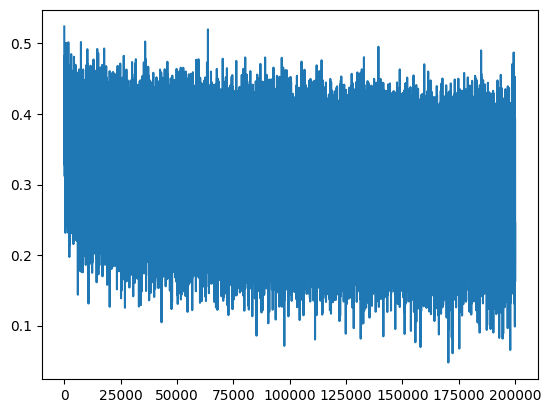

In [351]:
plt.plot(lossi)

In [349]:
for layer in model.layers:
        layer.training = False

In [350]:
@torch.no_grad()
def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
           'dev': (Xdev, Ydev),
           'test':(Xte, Yte)}[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(loss.item())
split_loss('dev')
split_loss('train')

2.03474497795105
1.9116144180297852


### Performance log
- previous : val 2.1268885135650635; train 2.058885335922241
- now : val 2.0400238037109375; train 1.9179611206054688
- wavenet : val 2.03474497795105; train 1.9116144180297852

### Expand the model scale

In [353]:
n_emb = 24
n_hidden = 128
model = Sequential([Embedding(vocab_size, n_emb), 
        FlattenConsecutive(2), Linear(n_emb * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
        FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
        FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
        Linear(n_hidden, vocab_size)])
with torch.no_grad():
    layers[-1].weight *= 0.1
parameters = model.parameters()
print(sum(p.numel() for p in parameters))
for p in parameters:
    p.requires_grad = True

76579


In [354]:
max_steps = 200000
batch_size = 32
lossi = []
for i in range(max_steps):
    ix = torch.randint(low = 0, high=Xtr.shape[0], size = (batch_size,))
    x, y = Xtr[ix], Ytr[ix]
    # print(x.shape)
    logits = model(x)
    # logits = logits.squeeze(1)
    # print(logits.shape)
    loss = F.cross_entropy(logits, y)
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    if (i % 10000) == 0 :
        print(f'{i} / {max_steps}: {loss.item()}')
    lossi.append(loss.log10().detach().item())

0 / 200000: 3.4980697631835938
10000 / 200000: 2.4023075103759766
20000 / 200000: 2.2880589962005615
30000 / 200000: 2.174642562866211
40000 / 200000: 1.672088623046875
50000 / 200000: 2.1103458404541016
60000 / 200000: 2.0556604862213135
70000 / 200000: 1.9878108501434326
80000 / 200000: 1.947044849395752
90000 / 200000: 2.0812034606933594
100000 / 200000: 1.858918309211731
110000 / 200000: 1.7036744356155396
120000 / 200000: 2.0273759365081787
130000 / 200000: 1.946651577949524
140000 / 200000: 1.709844708442688
150000 / 200000: 2.1807448863983154
160000 / 200000: 1.411705493927002
170000 / 200000: 1.682727575302124
180000 / 200000: 1.995800256729126
190000 / 200000: 1.765612244606018


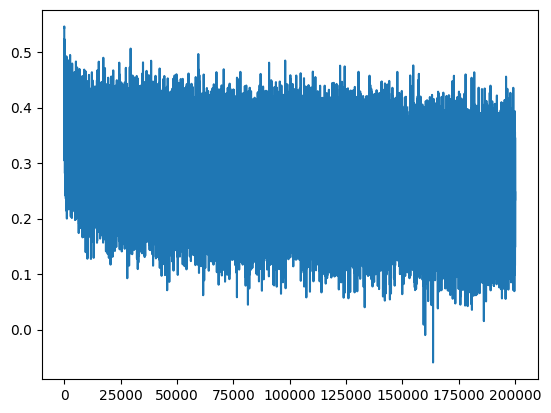

In [356]:
plt.plot(lossi)

In [357]:
@torch.no_grad()
def split_loss(split):
    x,y = {'train': (Xtr, Ytr),
           'dev': (Xdev, Ydev),
           'test':(Xte, Yte)}[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(loss.item())
split_loss('dev')
split_loss('train')

2.013410806655884
1.7683206796646118
